# Bài 2: Dry Bean Dataset — Logistic Regression vs KNN

**Mục tiêu:** Xây dựng mô hình phân loại 7 loại hạt đậu (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira)
bằng **Logistic Regression** và **K-Nearest Neighbors (KNN)**, sau đó so sánh kết quả.

Dữ liệu đã được xử lý và chia sẵn (theo `processing_seeds.ipynb`, `random_state=42`, `stratify`, tỷ lệ 80/20):
- `Dry_Bean_Dataset/dry_bean_train.csv`
- `Dry_Bean_Dataset/dry_bean_test.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Đọc dữ liệu train/test

In [2]:
train_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_train.csv")
test_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()


Train shape: (10834, 17)
Test shape : (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


In [3]:
print("Missing (train):", train_df.isna().sum().sum())
print("Missing (test) :", test_df.isna().sum().sum())

print("\nPhân bố lớp (train):")
print(train_df["class"].value_counts())


Missing (train): 0
Missing (test) : 0

Phân bố lớp (train):
class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


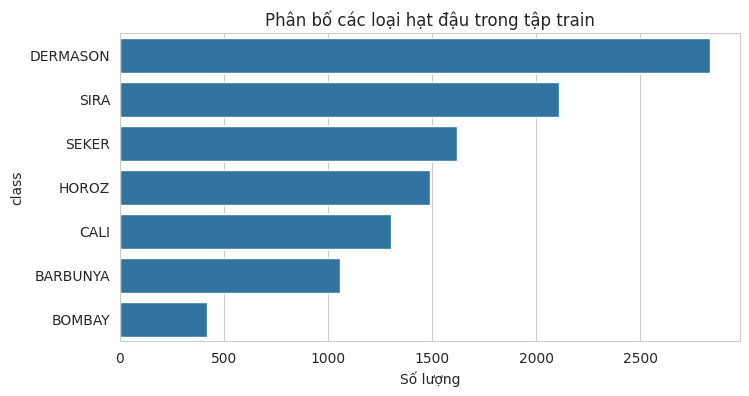

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(y="class", data=train_df, order=train_df["class"].value_counts().index)
plt.title("Phân bố các loại hạt đậu trong tập train")
plt.xlabel("Số lượng")
plt.show()


## 2. Tách feature/target và chuẩn hoá dữ liệu (StandardScaler)

In [5]:
target = "class"
features = [c for c in train_df.columns if c != target]

X_train = train_df[features].copy()
y_train_raw = train_df[target].copy()

X_test = test_df[features].copy()
y_test_raw = test_df[target].copy()

# Mã hoá nhãn dạng chữ -> số
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

print("Các lớp:", list(le.classes_))


Các lớp:

 ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [6]:
# Fit scaler trên train, transform cả train và test (tránh data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Logistic Regression (multi-class)

In [7]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log, average="macro")
rec_log = recall_score(y_test, y_pred_log, average="macro")
f1_log = f1_score(y_test, y_pred_log, average="macro")

print("=== Logistic Regression ===")
print(f"Accuracy       : {acc_log:.4f}")
print(f"Precision(macro): {prec_log:.4f}")
print(f"Recall(macro)   : {rec_log:.4f}")
print(f"F1-score(macro) : {f1_log:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_log, target_names=le.classes_))


=== Logistic Regression ===
Accuracy       : 0.9192
Precision(macro): 0.9307
Recall(macro)   : 0.9300
F1-score(macro) : 0.9302



Classification report:
               precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



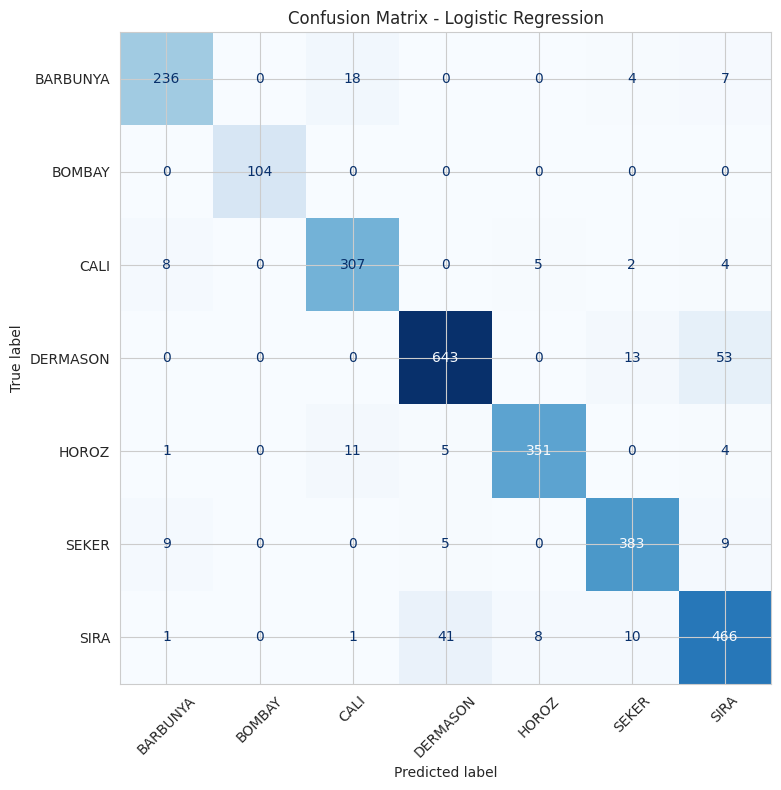

In [8]:
cm_log = confusion_matrix(y_test, y_pred_log)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=le.classes_)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


## 4. K-Nearest Neighbors (KNN)

Trước tiên tìm giá trị `k` phù hợp bằng cách thử một vài giá trị và so sánh accuracy qua GridSearchCV
(cross-validation trên tập train), sau đó huấn luyện lại với `k` tốt nhất và đánh giá trên tập test.

In [9]:
param_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15]}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print("Best k:", knn_grid.best_params_)
print("Best CV accuracy:", round(knn_grid.best_score_, 4))

results = pd.DataFrame(knn_grid.cv_results_)[["param_n_neighbors", "mean_test_score"]]
results.columns = ["k", "mean_cv_accuracy"]
results


Best k: {'n_neighbors': 15}
Best CV accuracy: 0.9253


,k,mean_cv_accuracy
0,3,0.919051
1,5,0.921543
2,7,0.923020
3,9,0.923390
4,11,0.924220
5,15,0.925328


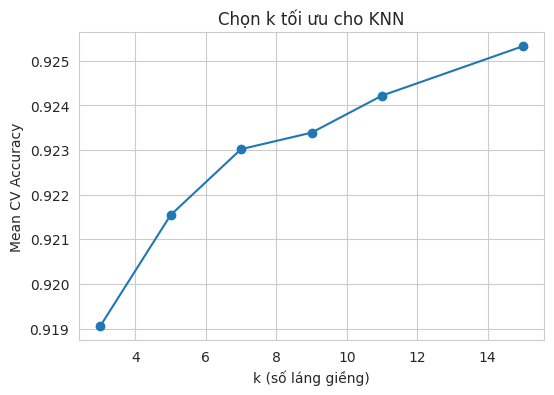

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(results["k"], results["mean_cv_accuracy"], marker="o")
plt.xlabel("k (số láng giềng)")
plt.ylabel("Mean CV Accuracy")
plt.title("Chọn k tối ưu cho KNN")
plt.show()


In [11]:
best_k = knn_grid.best_params_["n_neighbors"]
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="macro")
rec_knn = recall_score(y_test, y_pred_knn, average="macro")
f1_knn = f1_score(y_test, y_pred_knn, average="macro")

print(f"=== KNN (k={best_k}) ===")
print(f"Accuracy       : {acc_knn:.4f}")
print(f"Precision(macro): {prec_knn:.4f}")
print(f"Recall(macro)   : {rec_knn:.4f}")
print(f"F1-score(macro) : {f1_knn:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))


=== KNN (k=15) ===
Accuracy       : 0.9158
Precision(macro): 0.9312
Recall(macro)   : 0.9276
F1-score(macro) : 0.9290

Classification report:
               precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.96      0.93       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



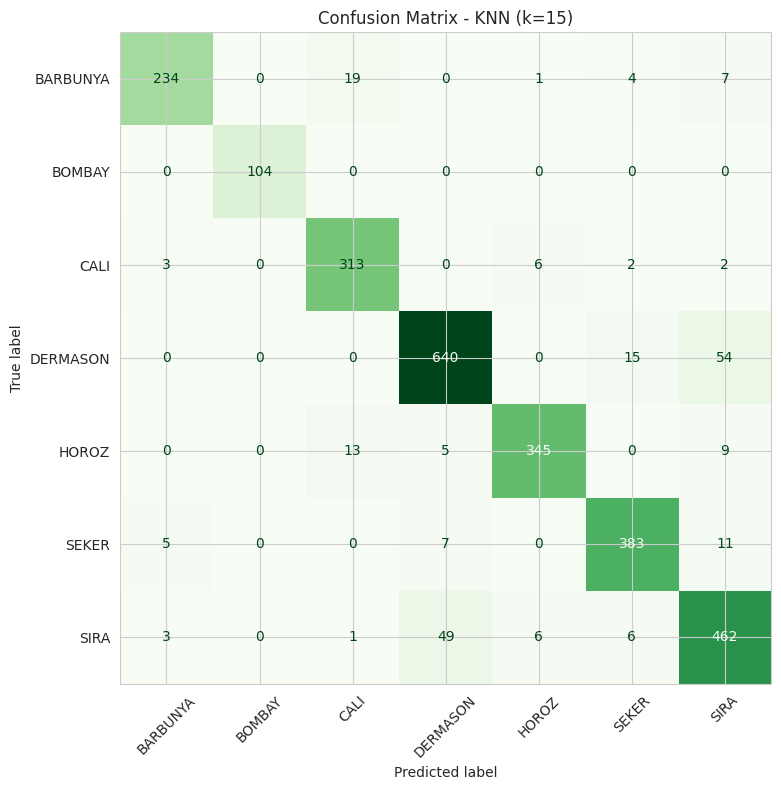

In [12]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp.plot(cmap="Greens", ax=ax, xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix - KNN (k={best_k})")
plt.tight_layout()
plt.show()


## 5. So sánh Logistic Regression vs KNN

In [13]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"],
    "Logistic Regression": [acc_log, prec_log, rec_log, f1_log],
    f"KNN (k={best_k})": [acc_knn, prec_knn, rec_knn, f1_knn],
})
comparison


,Metric,Logistic Regression,KNN (k=15)
0,Accuracy,0.919158,0.915836
1,Precision (macro),0.930725,0.931178
2,Recall (macro),0.930049,0.927607
3,F1-score (macro),0.930237,0.928981


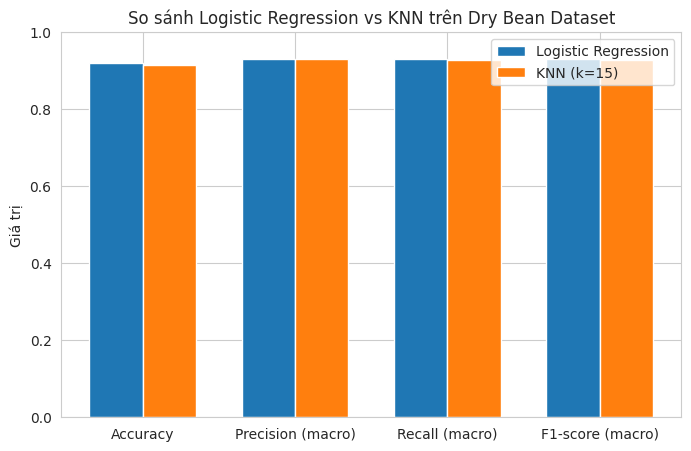

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Logistic Regression"], width, label="Logistic Regression")
ax.bar(x + width/2, comparison[f"KNN (k={best_k})"], width, label=f"KNN (k={best_k})")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"])
ax.set_ylim(0, 1)
ax.set_ylabel("Giá trị")
ax.set_title("So sánh Logistic Regression vs KNN trên Dry Bean Dataset")
ax.legend()
plt.show()


## 6. Nhận xét

- Cả hai mô hình đều được huấn luyện trên dữ liệu đã chuẩn hoá (`StandardScaler`) để đảm bảo công bằng
  giữa các đặc trưng có thang đo khác nhau (Area có giá trị hàng chục nghìn trong khi Eccentricity chỉ trong [0, 1]).
  Việc chuẩn hoá đặc biệt quan trọng với KNN vì thuật toán này dựa trên khoảng cách Euclidean.
- **Logistic Regression** học một ranh giới quyết định tuyến tính (hoặc gần tuyến tính) giữa các lớp,
  huấn luyện nhanh, dễ diễn giải (qua hệ số hồi quy), phù hợp khi dữ liệu có ranh giới lớp khá rõ ràng như Dry Bean.
- **KNN** không cần huấn luyện mô hình tường minh (lazy learning), phân loại dựa trên các điểm dữ liệu
  gần nhất; có thể nắm bắt ranh giới phi tuyến phức tạp hơn nhưng chi phí dự đoán cao hơn khi dữ liệu lớn
  và nhạy cảm với việc chọn `k`.
- Trên bộ Dry Bean (đặc trưng hình học tương đối tách biệt theo loại hạt), cả hai mô hình thường đạt
  accuracy khá cao (thường > 90%). Mô hình nào tốt hơn phụ thuộc vào kết quả cụ thể ở bảng so sánh trên —
  nhìn vào bảng và biểu đồ để kết luận mô hình nào phù hợp hơn cho bài toán này.